<a href="https://colab.research.google.com/github/ENRIQUESPECTER/Mineria-de-Datos/blob/main/DBSCAN_Ejercicios/DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Ejercicio 1 — Detección de zonas de entrega**

**Contexto: Una empresa de mensajería quiere identificar zonas de alta** **concentración de entregas y detectar direcciones atípicas (outliers).**

In [1538]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [1539]:
#1. Crear el DataFrame con columnas X y Y
df = pd.read_csv('ejercicio_1_zonas_entrega.csv')
df

,Punto,X,Y
0,P1,1.0,1.0
1,P2,1.2,1.3
2,P3,0.8,0.9
3,P4,1.1,1.0
4,P5,5.0,5.0
5,P6,5.2,5.1
6,P7,4.8,4.9
7,P8,5.1,5.2
8,P9,9.0,9.0
9,P10,9.3,9.1


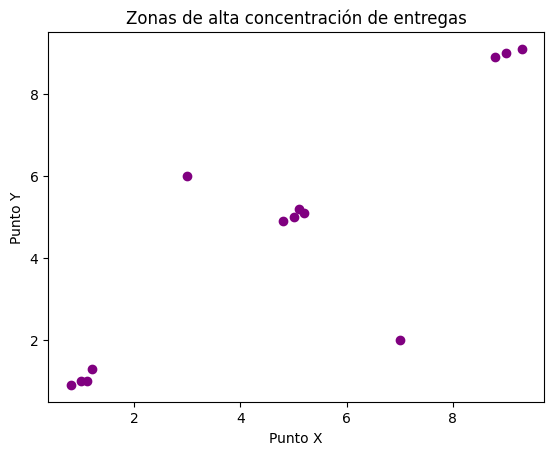

In [1540]:
#2. Graficar los puntos sin clasificar
plt.scatter(df['X'], df['Y'], c='purple')
plt.xlabel('Punto X')
plt.ylabel('Punto Y')
plt.title('Zonas de alta concentración de entregas')
plt.show()

In [1541]:
# Normalizar los datos con StandardScaler
puntos = df[['X', 'Y']].values
normalizar = StandardScaler().fit_transform(puntos)
normalizar

array([[-1.22668669, -1.18385068],
       [-1.16065387, -1.08434599],
       [-1.29271952, -1.21701891],
       [-1.19367028, -1.18385068],
       [ 0.09396979,  0.14287853],
       [ 0.16000261,  0.17604676],
       [ 0.02793696,  0.1097103 ],
       [ 0.1269862 ,  0.20921499],
       [ 1.41462627,  1.46960774],
       [ 1.51367551,  1.50277597],
       [ 1.34859345,  1.43643951],
       [-0.56635845,  0.47456083],
       [ 0.75429803, -0.85216838]])

In [1542]:
#3. Aplicar DBSCAN con eps=0.8 y min_samples=3
dbscan = DBSCAN(eps=0.5, min_samples=3)
clusters = dbscan.fit_predict(normalizar)

In [1543]:
#4. Agregar columna Cluster (donde -1 = ruido/outlier)
df['Cluster'] = clusters
print(df)

   Punto    X    Y  Cluster
0     P1  1.0  1.0        0
1     P2  1.2  1.3        0
2     P3  0.8  0.9        0
3     P4  1.1  1.0        0
4     P5  5.0  5.0        1
5     P6  5.2  5.1        1
6     P7  4.8  4.9        1
7     P8  5.1  5.2        1
8     P9  9.0  9.0        2
9    P10  9.3  9.1        2
10   P11  8.8  8.9        2
11   P12  3.0  6.0       -1
12   P13  7.0  2.0       -1


/tmp/ipykernel_2249/1198841252.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


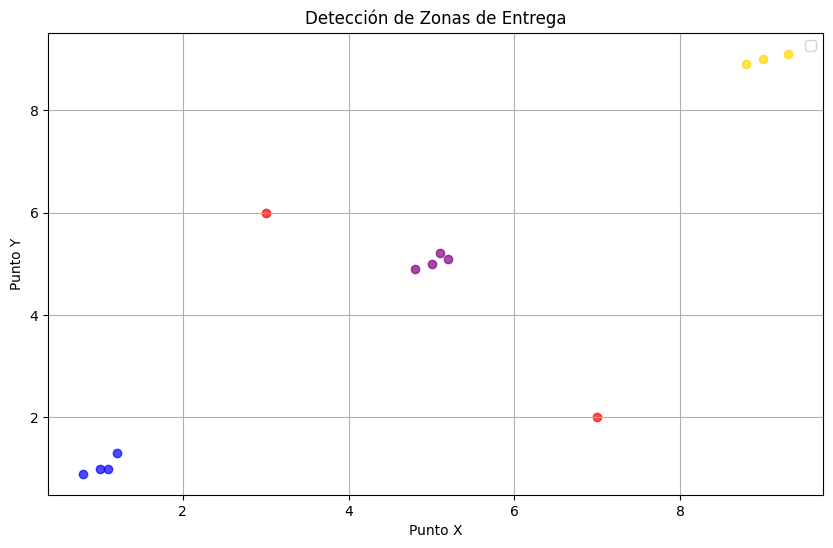

In [1544]:
#5. Graficar los clusters y resaltar los outliers en rojo
plt.figure(figsize=(10,6))
colors = {0:'blue', -1:'red', 1:'purple', 2:'gold'}

for clusters, group in df.groupby('Cluster'):
  plt.scatter(group['X'], group['Y'], color=colors[clusters], alpha=0.7)

plt.xlabel('Punto X')
plt.ylabel('Punto Y')
plt.title('Detección de Zonas de Entrega')
plt.legend()
plt.grid(True)
plt.show()


**6. ¿Cuántas zonas de entrega identificó el algoritmo?**

Identifico solamente 3 zonas de entrega

**Ejercicio 2 — Segmentación de sensores ambientales**

**Contexto: Una red de sensores registra temperatura y humedad. Se** **quiere detectar condiciones anómalas (outliers) y agrupar** **condiciones similares.**

In [1545]:
#1. Concatenar todos los datos en un DataFrame con columnas Temperatura y Humedad
df = pd.read_csv('ejercicio_2_sensores_ambientales.csv')
df

,Sensor,Temperatura_C,Humedad_pct,Tipo_Esperado
0,S1,10.2,20.5,Frio/Seco
1,S2,9.8,19.1,Frio/Seco
2,S3,11.1,21.0,Frio/Seco
3,S4,35.5,80.2,Calido/Humedo
4,S5,34.1,78.5,Calido/Humedo
5,S6,36.8,81.3,Calido/Humedo
6,S7,22.4,50.1,Templado
7,S8,21.9,49.5,Templado
8,S9,23.2,51.8,Templado
9,S10,50.0,10.0,ANOMALIA


In [1546]:
#2. Escalar los datos con StandardScaler antes de aplicar DBSCAN
data = df[['Temperatura_C','Humedad_pct']]
data_normalizada = StandardScaler().fit_transform(data)

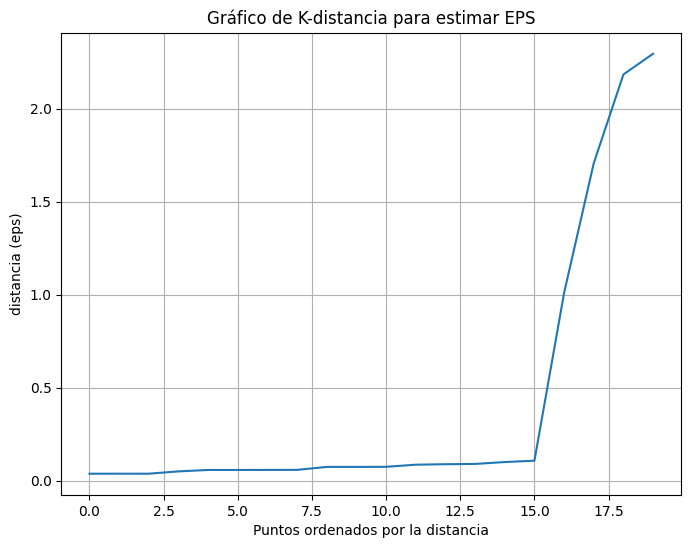

0.10840203445731551


In [1547]:
#3. Usar el gráfico k-distancia para elegir eps adecuado
# Configurar el numero de puntos minimos y de vecinos
min_pts = 3
vecindad = NearestNeighbors(n_neighbors=min_pts)
vecindad_fit = vecindad.fit(data_normalizada)
distance, indices = vecindad_fit.kneighbors(data_normalizada)
#Calcula la distancia del vecino mas cercano
distance = np.sort(distance[:, min_pts-1], axis=0)

plt.figure(figsize=(8,6))
plt.plot(distance)
plt.title('Gráfico de K-distancia para estimar EPS')
plt.xlabel('Puntos ordenados por la distancia')
plt.ylabel('distancia (eps)')
plt.grid(True)
plt.show()
print(distance[15])

In [1548]:
# 4. Aplicar DBSCAN y agregar columna Cluster
dbscan = DBSCAN(eps=0.1, min_samples=3)
clusters = dbscan.fit_predict(data_normalizada)
df['Cluster'] = clusters
df

,Sensor,Temperatura_C,Humedad_pct,Tipo_Esperado,Cluster
0,S1,10.2,20.5,Frio/Seco,0
1,S2,9.8,19.1,Frio/Seco,0
2,S3,11.1,21.0,Frio/Seco,0
3,S4,35.5,80.2,Calido/Humedo,1
4,S5,34.1,78.5,Calido/Humedo,1
5,S6,36.8,81.3,Calido/Humedo,1
6,S7,22.4,50.1,Templado,2
7,S8,21.9,49.5,Templado,2
8,S9,23.2,51.8,Templado,2
9,S10,50.0,10.0,ANOMALIA,-1


/tmp/ipykernel_2249/1009341429.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


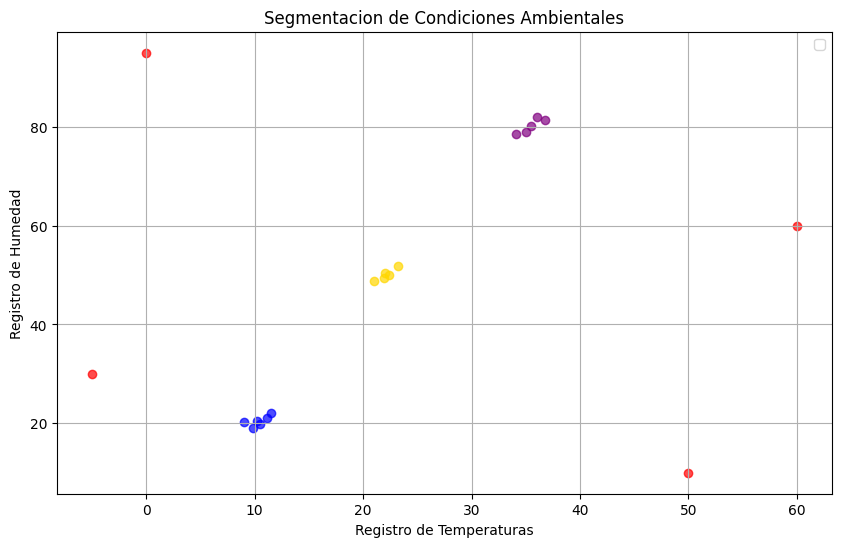

In [1549]:
# 5. Graficar los clusters + anomalías detectadas
plt.figure(figsize=(10,6))
colors = {0:'blue', -1:'red', 1:'purple', 2:'gold'}

for clusters, group in df.groupby('Cluster'):
  plt.scatter(group['Temperatura_C'], group['Humedad_pct'], color=colors[clusters], alpha=0.7)

plt.xlabel('Registro de Temperaturas')
plt.ylabel('Registro de Humedad')
plt.title('Segmentacion de Condiciones Ambientales')
plt.legend()
plt.grid(True)
plt.show()

**6. Comparar: ¿K-Means hubiera detectado las anomalías? ¿Por qué sí o no?**

Seguramente no las detectaría, debido que aun con mucha distancia encontrará un centroide al que pueda pertenecer cada punto.

**Ejercicio 3 — Análisis de patrones de fraude bancario**

**Contexto: Un banco quiere detectar transacciones fraudulentas** **basándose en el monto y la hora del día en que se realizaron.**

In [1550]:
#1. Crear DataFrame con columnas Monto y Hora
df = pd.read_csv('ejercicio_3_fraude_bancario.csv')
df

,Transaccion,Monto,Hora,Perfil_Real
0,T1,510,13,Normal
1,T2,480,14,Normal
2,T3,550,12,Normal
3,T4,460,15,Normal
4,T5,4500,3,SOSPECHOSA
5,T6,5000,2,SOSPECHOSA
6,T7,4800,1,SOSPECHOSA
7,T8,520,13,Normal
8,T9,490,14,Normal
9,T10,200,23,SOSPECHOSA


In [1551]:
#2. Escalar los datos con StandardScaler
data = df[['Monto', 'Hora']]
data_normalizada = StandardScaler().fit_transform(data)

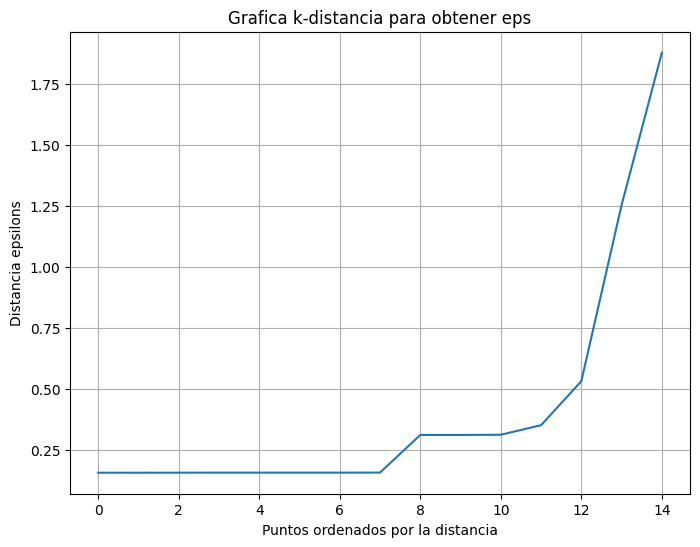

0.3107296354113523


In [1552]:
#3. Aplicar el gráfico k-distancia para determinar eps
min_pts = 3
vecinos = NearestNeighbors(n_neighbors=min_pts)
vecinos_fit = vecinos.fit(data_normalizada)
distance, indices = vecinos_fit.kneighbors(data_normalizada)
distance = np.sort(distance[:, min_pts-1], axis=0)

plt.figure(figsize=(8,6))
plt.plot(distance)
plt.xlabel('Puntos ordenados por la distancia')
plt.ylabel('Distancia epsilons')
plt.title('Grafica k-distancia para obtener eps')
plt.grid(True)
plt.show()

print(distance[8])

In [1553]:
#4. Aplicar DBSCAN y etiquetar cada transacción como Normal o Sospechosa
dbscan = DBSCAN(eps=0.31, min_samples=3)
clusters = dbscan.fit_predict(data_normalizada)

df['Cluster'] = clusters
df

,Transaccion,Monto,Hora,Perfil_Real,Cluster
0,T1,510,13,Normal,0
1,T2,480,14,Normal,0
2,T3,550,12,Normal,0
3,T4,460,15,Normal,0
4,T5,4500,3,SOSPECHOSA,-1
5,T6,5000,2,SOSPECHOSA,-1
6,T7,4800,1,SOSPECHOSA,-1
7,T8,520,13,Normal,0
8,T9,490,14,Normal,0
9,T10,200,23,SOSPECHOSA,-1


/tmp/ipykernel_2249/2709812559.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


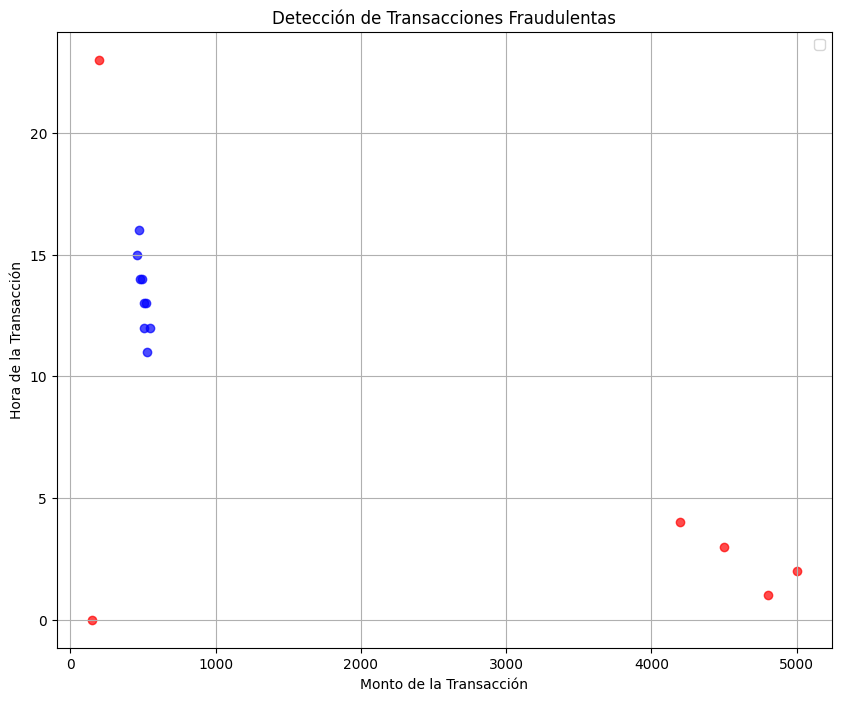

In [1554]:
#5. Graficar las transacciones diferenciando normales, clusters secundarios y fraudes detectados

plt.figure(figsize=(10,8))
colors = {0: 'blue', -1:'red'}

for clusters, group in df.groupby('Cluster'):
  plt.scatter(group['Monto'], group['Hora'], color=colors[clusters], alpha=0.7)

plt.xlabel('Monto de la Transacción')
plt.ylabel('Hora de la Transacción')
plt.title('Detección de Transacciones Fraudulentas')
plt.legend()
plt.grid(True)
plt.show()


In [1555]:
#6. Calcular el porcentaje de transacciones marcadas como sospechosas
perfil = {'Normal': 0, 'SOSPECHOSA': 1}
df['Perfil_Real'] = df['Perfil_Real'].map(perfil)
porcentaje = df['Perfil_Real'].sum() / df['Perfil_Real'].size * 100
print(f'El porcentaje de transacciones SOSPECHOSAS es {porcentaje}%')

El porcentaje de transacciones SOSPECHOSAS es 40.0%


**7. Reflexión: ¿Qué ventaja tiene DBSCAN sobre K-Means para detectar fraude?**

Debido a que DBSCAN siempre asegura de mostrar el ruido y de agrupar todo por densidad hace mas adecuadas las divisiones